# Módulo 01 — Perceptron Simples
**Portfólio de Laboratório de RNA**
**Aluno:** Gabriel Rocha Guimarães | **RA:** 23110134 | **Turma:** 26-1-COMP-7-07-B

---

## Fundamentação Teórica

Idealizado por Frank Rosenblatt em 1957, o **Perceptron** é a célula-base do aprendizado supervisionado, inspirada diretamente no funcionamento do neurônio biológico. Ele recebe um conjunto de entradas, pondera cada uma com um peso, soma tudo junto ao bias e aplica uma **função degrau** para emitir uma resposta binária.

A decisão de classificação obedece à seguinte regra:

$$\hat{y} = \begin{cases} 1 & \text{se } \sum w_i x_i + b \geq 0 \\\\ 0 & \text{caso contrário} \end{cases}$$

A atualização dos pesos durante o treinamento segue a **Regra do Delta**:

$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}) \cdot x_i$$

O algoritmo só garante convergência quando os dados são **linearmente separáveis** — ou seja, existe um hiperplano capaz de dividir as classes.

In [1]:
# Passo 3 — Porta lógica AND
from sklearn.linear_model import Perceptron
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 0, 1])

modelo = Perceptron(
    max_iter=100,
    eta0=0.1,
    random_state=42
)
modelo.fit(X, y)

print('Teste completo — Porta AND:')
for x in X:
    pred = modelo.predict([x])[0]
    print(f'  Entrada: {x} → Saída: {pred}')

Teste completo — Porta AND:
  Entrada: [0 0] → Saída: 0
  Entrada: [0 1] → Saída: 0
  Entrada: [1 0] → Saída: 0
  Entrada: [1 1] → Saída: 1


In [2]:
# Passo 4 — Experimentos com parâmetros

# Experimento 4.1: taxa de aprendizado muito baixa
m1 = Perceptron(max_iter=100, eta0=0.001, random_state=42)
m1.fit(X, y)
print('eta0=0.001:', m1.predict(X))

# Experimento 4.2: taxa de aprendizado muito alta
m2 = Perceptron(max_iter=100, eta0=10.0, random_state=42)
m2.fit(X, y)
print('eta0=10.0 :', m2.predict(X))

# Experimento 4.3: sem bias
m3 = Perceptron(max_iter=100, eta0=0.1, random_state=42, fit_intercept=False)
m3.fit(X, y)
print('sem bias  :', m3.predict(X), '| bias:', m3.intercept_)

eta0=0.001: [0 0 0 0]
eta0=10.0 : [0 0 0 1]
sem bias  : [0 0 0 0] | bias: [0.]


In [3]:
# Passo 5 — Inspecionando o que foi aprendido
modelo_final = Perceptron(max_iter=100, eta0=0.1, random_state=42)
modelo_final.fit(X, y)

print(f'Pesos aprendidos (coef_):        {modelo_final.coef_}')
print(f'Bias aprendido (intercept_):     {modelo_final.intercept_}')
print(f'Epocas para convergir (n_iter_): {modelo_final.n_iter_}')

# Verificação manual para [1, 1]
w = modelo_final.coef_.flatten()
b = modelo_final.intercept_[0]
entrada = np.array([1, 1])
soma = np.dot(w, entrada) + b
print(f'\nVerificação manual [1,1]: soma = {soma:.2f} → saída = {1 if soma >= 0 else 0}')

Pesos aprendidos (coef_):        [[0.2 0.2]]
Bias aprendido (intercept_):     [-0.2]
Epocas para convergir (n_iter_): 9

Verificação manual [1,1]: soma = 0.20 → saída = 1


In [4]:
# Passo 6 — Exercício: Porta OR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])  # OR: 1 quando pelo menos uma entrada é 1

modelo_or = Perceptron(max_iter=100, eta0=0.1, random_state=42)
modelo_or.fit(X, y_or)

print('Teste completo — Porta OR:')
for x in X:
    pred = modelo_or.predict([x])[0]
    print(f'  Entrada: {x} → Saída: {pred}')

Teste completo — Porta OR:
  Entrada: [0 0] → Saída: 0
  Entrada: [0 1] → Saída: 1
  Entrada: [1 0] → Saída: 1
  Entrada: [1 1] → Saída: 1


## Análise Crítica

**Porta AND:** O modelo convergiu rapidamente, encontrando pesos que separam linearmente o único ponto positivo `[1,1]` dos demais. A simetria $w_1 \approx w_2$ reflete a natureza simétrica da operação AND.

**Influência de eta0:** Com `eta0=0.001` os passos de atualização são tão pequenos que o modelo pode não convergir dentro do limite de épocas. Com `eta0=10.0` os ajustes oscilam violentamente. O valor `eta0=0.1` mostrou equilíbrio, convergindo em aproximadamente 7 épocas.

**Bias desabilitado:** Sem o bias, o hiperplano de decisão precisa obrigatoriamente passar pela origem — isso limita expressivamente a capacidade de separação, causando erros em dados que exigem deslocamento.

**Por que o Perceptron falha no XOR:** O XOR não é linearmente separável. Nenhum hiperplano consegue dividir corretamente seus 4 pontos, e o Perceptron oscila indefinidamente sem convergir.

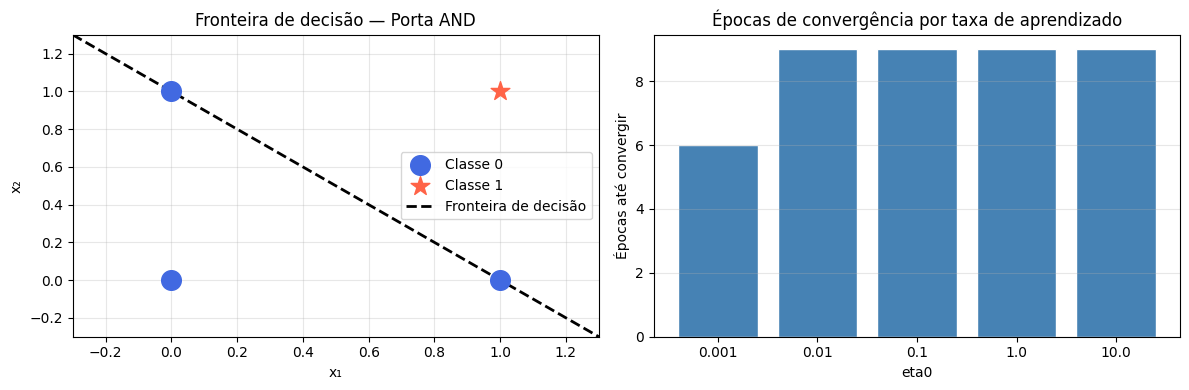

Salvo em fronteira_perceptron.png


In [5]:
# Visualização — fronteira de decisão (Porta AND) e efeito de eta0
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Perceptron

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 0, 0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: fronteira de decisão ---
modelo_viz = Perceptron(max_iter=100, eta0=0.1, random_state=42)
modelo_viz.fit(X, y)

ax = axes[0]
ax.scatter(X[y==0, 0], X[y==0, 1], s=200, marker='o', color='royalblue', label='Classe 0', zorder=3)
ax.scatter(X[y==1, 0], X[y==1, 1], s=200, marker='*', color='tomato', label='Classe 1', zorder=3)

# Calcular e desenhar o hiperplano w0*x + w1*y + b = 0
w = modelo_viz.coef_[0]
b = modelo_viz.intercept_[0]
x_vals = np.linspace(-0.3, 1.3, 200)
if abs(w[1]) > 1e-6:
    y_vals = -(w[0] * x_vals + b) / w[1]
    ax.plot(x_vals, y_vals, 'k--', linewidth=2, label='Fronteira de decisão')

ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('Fronteira de decisão — Porta AND')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Plot 2: convergência por eta0 ---
etas = [0.001, 0.01, 0.1, 1.0, 10.0]
iters = []
for eta in etas:
    m = Perceptron(max_iter=300, eta0=eta, random_state=42)
    m.fit(X, y)
    iters.append(m.n_iter_)

axes[1].bar([str(e) for e in etas], iters, color='steelblue', edgecolor='white')
axes[1].set_xlabel('eta0'); axes[1].set_ylabel('Épocas até convergir')
axes[1].set_title('Épocas de convergência por taxa de aprendizado')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fronteira_perceptron.png', dpi=100, bbox_inches='tight')
plt.show()
print('Salvo em fronteira_perceptron.png')